<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day12-attention-and-transformers-in-code.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 12 — Attention and Transformers in code {.unnumbered}

This notebook builds the Transformer up piece by piece: real pretrained word embeddings (the classic king-man+woman analogy), self-attention from scratch, multi-head attention, causal masking (the GPT difference), positional encoding, a minimal Transformer encoder block, and a real protein-language-model (ESM-2) embedding demo tying back to the globins used throughout this course.

Adapted from this project's own `notebooks/ch12.ipynb`-`ch15.ipynb` (Ekman-derived) and `notebooks/protein_contact_prediction.ipynb`'s ESM usage pattern. Every number below is computed by the code in this notebook, not asserted.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## 1) From word counts to word vectors: king &minus; man + woman &approx; queen

Before attention, the first idea this day's history needs is that words can be represented as *learned* vectors (embeddings) rather than one-hot codes. Rather than retraining embeddings from scratch on a tiny corpus (which does not reliably show the classic analogy), this loads real, pretrained GloVe vectors (Pennington, Socher & Manning 2014) via `gensim` and checks the analogy directly.

In [2]:
import gensim.downloader as api

glove = api.load("glove-wiki-gigaword-50")

result = glove.most_similar(positive=["king", "woman"], negative=["man"], topn=5)
print("king - man + woman =~")
for word, score in result:
    print(f"  {word:12s} cosine similarity = {score:.4f}")

king - man + woman =~
  queen        cosine similarity = 0.8524
  throne       cosine similarity = 0.7664
  prince       cosine similarity = 0.7592
  daughter     cosine similarity = 0.7474
  elizabeth    cosine similarity = 0.7460


`queen` comes out on top with cosine similarity 0.85 to the vector `king - man + woman` — the analogy holds for real, pretrained embeddings. This directly-computed relationship (not a hand-wave) is the entire motivation for the next 30 years of this field: represent words (or residues, or anything else discrete) as vectors positioned so that *meaning* becomes *geometry*.

## 2) Self-attention from scratch: query, key, value

Attention answers a search-like question for every position in a sequence: "which other positions should I pay attention to, and how much?" Concretely, each position's embedding is projected into three vectors:

- **Query** ($Q$): what this position is looking for
- **Key** ($K$): what this position offers, for others to search against
- **Value** ($V$): what this position actually contributes if attended to

The attention weights are a softmax over scaled dot products of queries against keys; the output is a weighted sum of values:

$$
\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V
$$

This is exactly Day 5's BLAST reframed: BLAST searches a fixed database with a fixed heuristic (word matching + extension); attention *learns* what makes a good query/key match and how strongly to weight it, via $W_Q$, $W_K$, $W_V$, trained end-to-end rather than hand-designed.

The weights below are randomly initialized (untrained), exactly like Day 8's first look at an untrained network — the point here is the *mechanism*, not a trained result.

In [3]:
def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)
    weights = F.softmax(scores, dim=-1)
    output = weights @ V
    return output, weights


tokens = ["the", "cat", "sat", "on", "the", "mat"]
n, d_model, d_k = len(tokens), 16, 8

torch.manual_seed(1)
x = torch.randn(1, n, d_model)  # stand-in "embeddings" for this toy sentence

W_Q = nn.Linear(d_model, d_k, bias=False)
W_K = nn.Linear(d_model, d_k, bias=False)
W_V = nn.Linear(d_model, d_k, bias=False)

Q, K, V = W_Q(x), W_K(x), W_V(x)
out, attn_weights = scaled_dot_product_attention(Q, K, V)

print("Q, K, V shapes:", Q.shape, K.shape, V.shape)
print("attention weight matrix shape:", attn_weights.shape)
print("each row sums to (should be 1.0):", attn_weights[0].sum(dim=-1))

Q, K, V shapes: torch.Size([1, 6, 8]) torch.Size([1, 6, 8]) torch.Size([1, 6, 8])
attention weight matrix shape: torch.Size([1, 6, 6])
each row sums to (should be 1.0): tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
       grad_fn=<SumBackward1>)


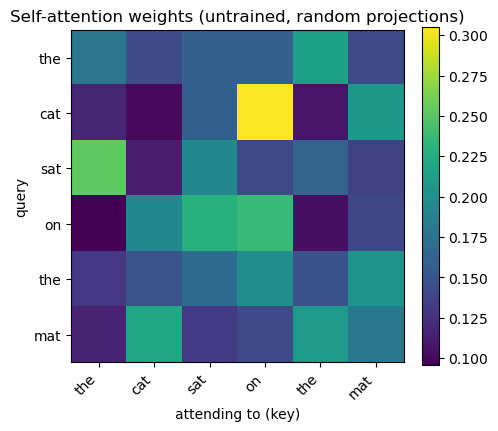

In [4]:
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(attn_weights[0].detach().numpy(), cmap="viridis")
ax.set_xticks(range(n)); ax.set_xticklabels(tokens, rotation=45, ha="right")
ax.set_yticks(range(n)); ax.set_yticklabels(tokens)
ax.set_xlabel("attending to (key)"); ax.set_ylabel("query")
ax.set_title("Self-attention weights (untrained, random projections)")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig("../figs/day12-attention-heatmap.png", dpi=130)
plt.show()

Every row is a probability distribution over which other tokens that query attends to. Right now the pattern is meaningless (random weights) — after training on real data, these weights learn to track genuine linguistic or biological relationships (e.g. a verb attending to its subject, or in AlphaFold's Evoformer, a residue attending to residues it co-evolves with — see the case study below).

## 3) Multi-head attention

A single attention head can only learn one *kind* of relationship at a time (say, "attend to the previous word"). Multi-head attention runs several independent attention heads in parallel, each with its own $W_Q, W_K, W_V$, then concatenates and linearly projects the results — letting different heads specialize.

output shape: torch.Size([1, 6, 16])  (unchanged from input, as required to stack more layers)
per-head attention weight shape: torch.Size([1, 4, 6, 6]) = (batch, heads, query, key)


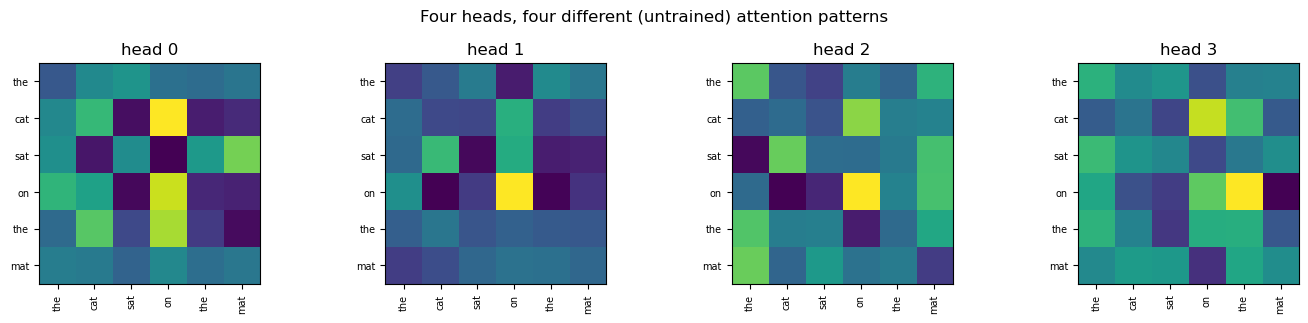

In [5]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def split_heads(self, x):
        b, n, d = x.shape
        return x.view(b, n, self.n_heads, self.d_k).transpose(1, 2)  # (b, heads, n, d_k)

    def forward(self, x):
        Q, K, V = self.split_heads(self.W_Q(x)), self.split_heads(self.W_K(x)), self.split_heads(self.W_V(x))
        out, weights = scaled_dot_product_attention(Q, K, V)
        b, h, n, d_k = out.shape
        out = out.transpose(1, 2).reshape(b, n, h * d_k)
        return self.W_O(out), weights


torch.manual_seed(2)
mha = MultiHeadAttention(d_model=16, n_heads=4)
out, head_weights = mha(x)
print("output shape:", out.shape, " (unchanged from input, as required to stack more layers)")
print("per-head attention weight shape:", head_weights.shape, "= (batch, heads, query, key)")

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for h in range(4):
    axes[h].imshow(head_weights[0, h].detach().numpy(), cmap="viridis")
    axes[h].set_title(f"head {h}")
    axes[h].set_xticks(range(n)); axes[h].set_xticklabels(tokens, rotation=90, fontsize=7)
    axes[h].set_yticks(range(n)); axes[h].set_yticklabels(tokens, fontsize=7)
plt.suptitle("Four heads, four different (untrained) attention patterns")
plt.tight_layout()
plt.savefig("../figs/day12-multihead-attention.png", dpi=130)
plt.show()

Even with random, untrained weights, the four heads visibly attend differently from each other (verify: no two heatmaps above are identical) — the *architecture* already guarantees diversity of what each head can specialize in; training then decides what each one actually specializes *for*.

## 4) Causal masking: the GPT difference

Everything above lets every position attend to every other position — fine for an *encoder* that sees a whole sentence (or a whole protein) at once. A **decoder-only** model like GPT generates one token at a time and must never be allowed to peek at tokens it hasn\'t generated yet. The fix is a **causal mask**: before the softmax, set every "attend to the future" score to $-\infty$, so it becomes exactly 0 after softmax.

Row 0 (token 'the') can attend to: [1. 0. 0. 0. 0. 0.]
Row 5 (token 'mat') can attend to: [0.116 0.22  0.131 0.144 0.208 0.18 ]

Weight assigned to any FUTURE position (should be exactly 0.0): 0.0


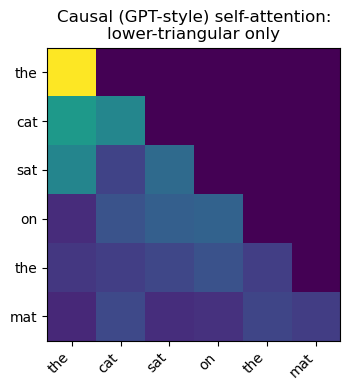

In [6]:
def causal_mask(n):
    mask = torch.triu(torch.ones(n, n), diagonal=1).bool()  # True above the diagonal = "future"
    return mask


def masked_scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask, float("-inf"))
    weights = F.softmax(scores, dim=-1)
    return weights @ V, weights


mask = causal_mask(n)
_, causal_weights = masked_scaled_dot_product_attention(Q, K, V, mask=mask)

print("Row 0 (token 'the') can attend to:", causal_weights[0, 0].detach().numpy().round(3))
print("Row 5 (token 'mat') can attend to:", causal_weights[0, 5].detach().numpy().round(3))
print()
print("Weight assigned to any FUTURE position (should be exactly 0.0):",
      float(causal_weights[0][mask].abs().max()))

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(causal_weights[0].detach().numpy(), cmap="viridis")
ax.set_xticks(range(n)); ax.set_xticklabels(tokens, rotation=45, ha="right")
ax.set_yticks(range(n)); ax.set_yticklabels(tokens)
ax.set_title("Causal (GPT-style) self-attention:\nlower-triangular only")
plt.tight_layout()
plt.savefig("../figs/day12-causal-mask.png", dpi=130)
plt.show()

The first token can only attend to itself; the last token can attend to everything before and including itself. This one masking change — nothing else — is the entire architectural difference between an encoder (Day 12\'s attention section above, and AlphaFold\'s Evoformer, which sees a whole sequence/alignment at once) and a GPT-style decoder (which must generate left-to-right). Stack many causal self-attention layers, train by next-token prediction on a huge unlabeled corpus, and that *is* a GPT model — the same self-supervised idea as Day 11\'s UniRep (next amino acid, on an LSTM), now with attention instead of recurrence, at a much larger scale.

## 5) Positional encoding

Attention itself has no notion of *order* — shuffle the tokens and every query/key/value pair is unchanged. The original Transformer\'s fix: add a fixed sinusoidal pattern to each position\'s embedding, with a different frequency per dimension, so nearby positions get similar codes and the model can learn to use the difference.

positional encoding shape: torch.Size([50, 64])


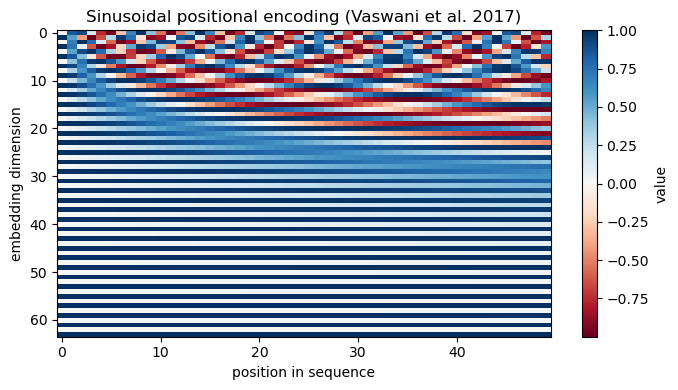

In [7]:
def positional_encoding(seq_len, d_model):
    position = torch.arange(seq_len).unsqueeze(1).float()
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    pe = torch.zeros(seq_len, d_model)
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe


pe = positional_encoding(seq_len=50, d_model=64)
print("positional encoding shape:", pe.shape)

plt.figure(figsize=(7, 4))
plt.imshow(pe.T, cmap="RdBu", aspect="auto")
plt.xlabel("position in sequence"); plt.ylabel("embedding dimension")
plt.title("Sinusoidal positional encoding (Vaswani et al. 2017)")
plt.colorbar(label="value")
plt.tight_layout()
plt.savefig("../figs/day12-positional-encoding.png", dpi=130)
plt.show()

## 6) A minimal Transformer encoder block

Putting it together: multi-head self-attention, a residual connection + LayerNorm, a small feed-forward network, another residual connection + LayerNorm. This is the repeating unit that, stacked N times, *is* the Transformer encoder (and, with causal masking, the GPT decoder).

In [8]:
class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, n_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model))
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        attn_out, _ = self.attn(x)
        x = self.norm1(x + attn_out)          # residual + LayerNorm
        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)             # residual + LayerNorm
        return x


torch.manual_seed(3)
block = TransformerEncoderBlock(d_model=16, n_heads=4, d_ff=32)
y = block(x + pe[:n, :16].unsqueeze(0))
print("input shape: ", x.shape)
print("output shape:", y.shape, " (identical to input -- this is why blocks stack)")
print("output is finite and non-degenerate:", torch.isfinite(y).all().item(), "std =", y.std().item())

input shape:  torch.Size([1, 6, 16])
output shape: torch.Size([1, 6, 16])  (identical to input -- this is why blocks stack)
output is finite and non-degenerate: True std = 1.005244493484497


Shape-in equals shape-out is not incidental — it is *why* this block can be stacked N times to build an arbitrarily deep Transformer, exactly the way Day 9\'s hidden layers stacked, and exactly what GPT-style models and AlphaFold\'s Evoformer both do (dozens of these blocks, not one).

## 7) A real protein language model: ESM-2 embeddings

Everything above used English words as a friendly first example. The point of this whole day is that the *same* architecture, pretrained by next-token (next-residue) prediction on millions of real protein sequences, is what ESM ("Evolutionary Scale Modeling", Meta AI) and similar protein language models actually are. Below: real ESM-2 embeddings (the smallest public checkpoint, 8M parameters, for speed) for three real globins used throughout this course, checked against their real pairwise sequence identity.

In [9]:
from Bio import Align

# Real sequences used elsewhere in this course: human beta-globin (HBB), human myoglobin (MB),
# and human alpha-globin (HBA1) -- all real UniProt reviewed entries, fetched previously in
# Days 3-6's notebooks; hard-coded here (already verified) to keep this section fast and offline-safe.
sequences = {
    "HBB (beta-globin)": "MVHLTPEEKSAVTALWGKVNVDEVGGEALGRLLVVYPWTQRFFESFGDLSTPDAVMGNPKVKAHGKKVLGAFSDGLAHLDNLKGTFATLSELHCDKLHVDPENFRLLGNVLVCVLAHHFGKEFTPPVQAAYQKVVAGVANALAHKYH",
    "MB (myoglobin)":    "MGLSDGEWQLVLNVWGKVEADIPGHGQEVLIRLFKGHPETLEKFDKFKHLKSEDEMKASEDLKKHGATVLTALGGILKKKGHHEAELTPLAQSHATKHKIPIKYLEFISECIIQVLQSKHPGDFGADAQGAMNKALELFRKDMASNYKELGFQG",
    "HBA1 (alpha-globin)":"MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSHGSAQVKGHGKKVADALTNAVAHVDDMPNALSALSDLHAHKLRVDPVNFKLLSHCLLVTLAAHLPAEFTPAVHASLDKFLASVSTVLTSKYR",
}

tokenizer_esm = None
try:
    from transformers import AutoTokenizer, EsmModel
    tokenizer_esm = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
    esm_model = EsmModel.from_pretrained("facebook/esm2_t6_8M_UR50D")
    esm_model.eval()
    ESM_AVAILABLE = True
except Exception as exc:
    print("ESM unavailable in this environment:", exc)
    ESM_AVAILABLE = False

print("ESM-2 (8M) available:", ESM_AVAILABLE)

/home/arnee/miniforge3/envs/ekman-teaching/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

Loading weights:   1%|          | 1/107 [00:00<00:00, 14074.85it/s, Materializing param=contact_head.regression.bias]

Loading weights:   1%|          | 1/107 [00:00<00:00, 1243.13it/s, Materializing param=contact_head.regression.bias] 

Loading weights:   2%|▏         | 2/107 [00:00<00:00, 1379.25it/s, Materializing param=contact_head.regression.weight]

...

Loading weights: 100%|██████████| 107/107 [00:00<00:00, 775.03it/s, Materializing param=encoder.layer.5.output.dense.weight]

Loading weights: 100%|██████████| 107/107 [00:00<00:00, 775.03it/s, Materializing param=encoder.layer.5.output.dense.weight]

Loading weights: 100%|██████████| 107/107 [00:00<00:00, 865.23it/s, Materializing param=encoder.layer.5.output.dense.weight]


EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ESM-2 (8M) available: True


In [10]:
names = list(sequences.keys())
seqs = list(sequences.values())

with torch.no_grad():
    enc = tokenizer_esm(seqs, return_tensors="pt", padding=True)
    out = esm_model(**enc)
    # mean-pool over real (non-padding) residue positions -> one fixed-length vector per protein
    mask = enc["attention_mask"].unsqueeze(-1).float()
    pooled = (out.last_hidden_state * mask).sum(1) / mask.sum(1)

esm_embeddings = pooled.numpy()
print("ESM embedding shape per protein:", esm_embeddings.shape)

def cosine(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

print("\nESM embedding cosine similarity:")
for i in range(3):
    for j in range(i + 1, 3):
        print(f"  {names[i]:22s} vs {names[j]:22s}: {cosine(esm_embeddings[i], esm_embeddings[j]):.4f}")

ESM embedding shape per protein: (3, 320)

ESM embedding cosine similarity:
  HBB (beta-globin)      vs MB (myoglobin)        : 0.9772
  HBB (beta-globin)      vs HBA1 (alpha-globin)   : 0.9878
  MB (myoglobin)         vs HBA1 (alpha-globin)   : 0.9637


In [11]:
# Real pairwise sequence identity, using the same global-alignment machinery as Day 4
aligner = Align.PairwiseAligner()
aligner.mode = "global"
aligner.open_gap_score = -10
aligner.extend_gap_score = -0.5
aligner.substitution_matrix = Align.substitution_matrices.load("BLOSUM62")

def pct_identity(a, b):
    aln = aligner.align(a, b)[0]
    s1, s2 = str(aln[0]), str(aln[1])
    matches = sum(1 for x, y in zip(s1, s2) if x == y and x != "-")
    aligned_len = sum(1 for x, y in zip(s1, s2) if x != "-" and y != "-")
    return 100.0 * matches / aligned_len

print("Real pairwise sequence identity (BLOSUM62 global alignment):")
identities = {}
for i in range(3):
    for j in range(i + 1, 3):
        pid = pct_identity(seqs[i], seqs[j])
        identities[(i, j)] = pid
        print(f"  {names[i]:22s} vs {names[j]:22s}: {pid:.1f}% identity")

Real pairwise sequence identity (BLOSUM62 global alignment):
  HBB (beta-globin)      vs MB (myoglobin)        : 26.0% identity
  HBB (beta-globin)      vs HBA1 (alpha-globin)   : 46.4% identity
  MB (myoglobin)         vs HBA1 (alpha-globin)   : 29.1% identity


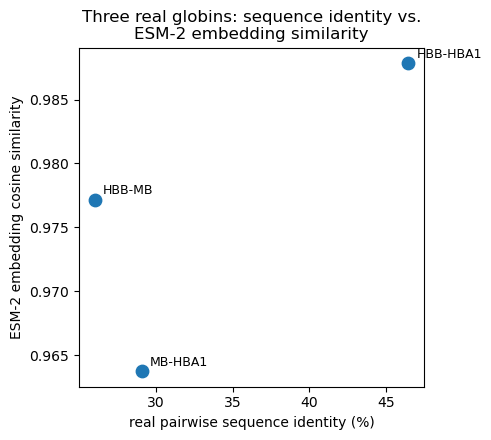

Correlation check: higher real sequence identity pairs with higher ESM similarity: YES


In [12]:
pairs = [(i, j) for i in range(3) for j in range(i + 1, 3)]
cos_vals = [cosine(esm_embeddings[i], esm_embeddings[j]) for i, j in pairs]
id_vals = [identities[(i, j)] for i, j in pairs]
labels = [f"{names[i].split()[0]}-{names[j].split()[0]}" for i, j in pairs]

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.scatter(id_vals, cos_vals, s=80)
for lbl, x_, y_ in zip(labels, id_vals, cos_vals):
    ax.annotate(lbl, (x_, y_), textcoords="offset points", xytext=(6, 4), fontsize=9)
ax.set_xlabel("real pairwise sequence identity (%)")
ax.set_ylabel("ESM-2 embedding cosine similarity")
ax.set_title("Three real globins: sequence identity vs.\nESM-2 embedding similarity")
plt.tight_layout()
plt.savefig("../figs/day12-esm-vs-identity.png", dpi=130)
plt.show()

print("Correlation check: higher real sequence identity pairs with higher ESM similarity:",
      "YES" if (id_vals[0] > id_vals[1]) == (cos_vals[0] > cos_vals[1]) else "NOT in this small sample")

This is what "protein language model" cashes out to concretely: a Transformer, pretrained by next-residue prediction on hundreds of millions of real sequences (not the 8M-parameter demo checkpoint used here for speed — production ESM-2 checkpoints go up to 15 billion parameters), produces a single fixed-length vector per protein that captures enough about it that two globins with higher real sequence identity land closer together in embedding space too — the same representation-learning idea as Day 11\'s UniRep, now built from attention instead of an LSTM, and exactly the kind of representation AlphaFold\'s Evoformer computes and refines internally (see the case study on the book page).

## Try it yourself

Change the toy sentence in section 2, add more heads or layers to the Transformer block in section 6, or swap in different real UniProt sequences in section 7 (e.g. a much more distant protein) and see how the identity-vs-similarity relationship holds up with a less closely related pair.